In [1]:
import numpy as np
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from utils import *
from plot import *
from sympy import symbols
import matplotlib.tri as tri

In [2]:
def plotT6Mesh(points, conn, nodal_field=None, axis=None, linestyle='-'):
    ax = plt.gca()

    points_used = points.copy()
    triangles = []

    # --- Gestion du champ nodal ---
    if nodal_field is not None:
        nodal_field = nodal_field.reshape(points.shape[0], -1)

        if nodal_field.shape[1] > 1:
            if axis is None:
                print("⚠️ Attention : champ vectoriel détecté, utilisation de la norme ||u||. "
                      "Passez axis=0 ou axis=1 pour une composante spécifique.")
                nodal_field_used = np.linalg.norm(nodal_field, axis=1).reshape(-1, 1)
            else:
                nodal_field_used = nodal_field[:, axis].reshape(-1, 1)
        else:
            nodal_field_used = nodal_field.copy()
    else:
        nodal_field_used = None

    # --- Construction des triangles (découpe T6) ---
    for tri6 in conn:
        n0, n1, n2, m0, m1, m2 = tri6

        # Centre du triangle
        x_centre = (points[n0][0] + points[n1][0] + points[n2][0]) / 3
        y_centre = (points[n0][1] + points[n1][1] + points[n2][1]) / 3
        centre_index = len(points_used)
        points_used = np.vstack([points_used, [x_centre, y_centre]])

        if nodal_field is not None:
            valeur_centre = (nodal_field_used[n0] + nodal_field_used[n1] + nodal_field_used[n2]) / 3
            nodal_field_used = np.vstack([nodal_field_used, valeur_centre.reshape(1, -1)])

        # Ajoute 6 triangles pour T6
        triangles += [
            [n0, m0, centre_index],
            [m0, n1, centre_index],
            [n1, m1, centre_index],
            [m1, n2, centre_index],
            [n2, m2, centre_index],
            [m2, n0, centre_index],
        ]

    triangles = np.array(triangles)
    triang = tri.Triangulation(points_used[:, 0], points_used[:, 1], triangles)

    # --- Affichage du champ nodal ---
    if nodal_field is not None:
        contour = plt.tricontourf(triang, nodal_field_used[:, 0], cmap='viridis')
        plt.colorbar(contour)

    # --- Arêtes réelles du T6 + points rouges ---
    for triangle in conn:
        coords = points[triangle]
        edges = [(0, 3), (3, 1), (1, 4), (4, 2), (2, 5), (5, 0)]

        # Affiche les arêtes
        for i1, i2 in edges:
            x = [coords[i1][0], coords[i2][0]]
            y = [coords[i1][1], coords[i2][1]]
            ax.plot(x, y, 'k', linestyle=linestyle, linewidth=1.5)

        # Affiche les 6 nœuds rouges (coins + milieux d’arêtes)
        for i in range(6):
            ax.plot(coords[i][0], coords[i][1], 'ro', markersize=4)

    ax.set_aspect('equal')
    ax.grid(True)

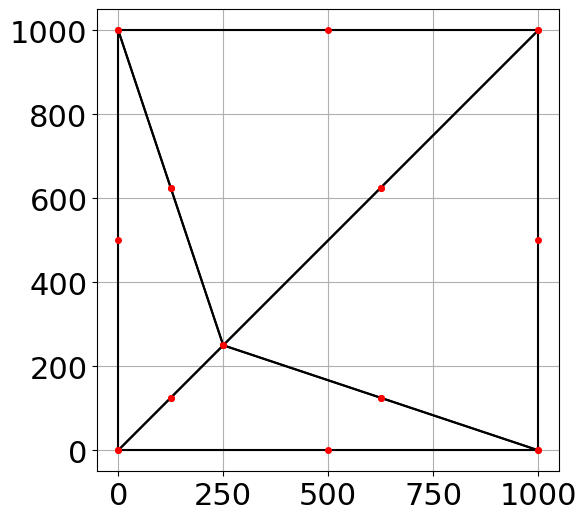

In [3]:


# --- 1. Nœuds principaux (sommets + centre)
points = np.array([
    [0.0, 0.0],    # 0
    [1000, 0.0],    # 1
    [0.0, 1000],    # 2
    [1000, 1000],    # 3
    [250, 250],  # 4 - centre
])

# Milieux de chaque arête
milieux = np.array([
    (points[0] + points[1]) / 2,  # 5
    (points[1] + points[4]) / 2,  # 6
    (points[4] + points[0]) / 2,  # 7

    (points[1] + points[3]) / 2,  # 8
    (points[3] + points[4]) / 2,  # 9

    (points[3] + points[2]) / 2,  # 10
    (points[2] + points[4]) / 2,  # 11

    (points[2] + points[0]) / 2,  # 12
])

# Ajoute les milieux aux points
points_T6 = np.vstack([points, milieux])

# --- 3. Connectivité T6 : chaque triangle a 6 nœuds
conn_T6 = np.array([
    [0, 1, 4, 5, 6, 7],    # triangle 0
    [1, 3, 4, 8, 9, 6],    # triangle 1
    [3, 2, 4, 10, 11, 9],    # triangle 2
    [2, 0, 4, 12, 7, 11]     # triangle 3
])

# --- 4. Affichage du maillage (optionnel)
plotT6Mesh(points_T6, conn_T6, nodal_field=None)


In [4]:
def calculerD(contraintes_planes=True):
    
    E = 210e3 # 210GPa = 210e9 N/m^2 = 210e3 N/mm^2
    nu = 0.3    

    # On fait des contraintes planes par défaut
    if contraintes_planes:
        D = (E/(1-nu**2))* np.array(
            [[1,  nu, 0],
             [nu, 1,  0],
             [0,  0,  (1-nu)/2]])
    else:
        raise RuntimeError('Déformations planes à implémenter!')
    return D

In [5]:
# Coord iso, définitions des fonctions N et propriétés

import sympy as sp

# 1. Définir les variables naturelles
s, t = sp.symbols('s t')

# 2. Définir les fonctions de forme symboliques T6
N1 = (1 - s - t)*(1 - 2*s - 2*t)
N2 = s*(2*s - 1)
N3 = t*(2*t - 1)
N4 = 4*s*(1 - s - t)
N5 = 4*s*t
N6 = 4*t*(1 - s - t)

# Liste des Ni
Ni_list = [N1, N2, N3, N4, N5, N6]

# 3. Vérifier que la somme des Ni = 1
somme_N = sp.simplify(sum(Ni_list))
print("Somme N1 à N6:", somme_N)
assert somme_N == 1, "Erreur: La somme des Ni ≠ 1"

# 4. Vérification de la propriété delta_ij
# Points de référence pour T6 : sommets + milieux d’arêtes
points_ref = [
    (0, 0),       # N1
    (1, 0),       # N2
    (0, 1),       # N3
    (0.5, 0),     # N4
    (0.5, 0.5),   # N5
    (0, 0.5)      # N6
]

# Matrice de vérification : Ni(sj,tj)
delta_check = []
for i, Ni in enumerate(Ni_list):
    row = []
    for (sj, tj) in points_ref:
        val = Ni.subs({s: sj, t: tj})
        row.append(sp.simplify(val))
    delta_check.append(row)

# Affichage
print("\nMatrice Ni(xj) :")
for row in delta_check:
    formatted = []
    for val in row:
        val = sp.simplify(val).evalf(chop=True)
        if val == int(val):
            formatted.append(int(val))  # Affiche 1 au lieu de 1.000000
        else:
            formatted.append(float(val))  # Sinon garde le flottant
    print(formatted)

print("\n✅ Toutes vérifications symboliques réussies pour T6 !")


Somme N1 à N6: 1

Matrice Ni(xj) :
[1.0, 0, 0, 0, 0, 0]
[0, 1.0, 0, 0, 0, 0]
[0, 0, 1.0, 0, 0, 0]
[0, 0, 0, 1.0, 0, 0]
[0, 0, 0, 0, 1.0, 0]
[0, 0, 0, 0, 0, 1.0]

✅ Toutes vérifications symboliques réussies pour T6 !


In [6]:
#calcul de la matrice C(s,t)
def C_matrix_T6(s, t):
    # Dérivées manuelles de N_i(s, t)
    N1s, N1t = 4*s + 4*t - 3,     4*s + 4*t - 3
    N2s, N2t = 4*s - 1,           0
    N3s, N3t = 0,                 4*t - 1
    N4s, N4t = 4 - 8*s - 4*t,     -4*s
    N5s, N5t = 4*t,               4*s
    N6s, N6t = -4*t,              4 - 4*s - 8*t


    C = np.array([
        [N1s, 0, N2s, 0, N3s, 0, N4s, 0, N5s, 0, N6s, 0],
        [N1t, 0, N2t, 0, N3t, 0, N4t, 0, N5t, 0, N6t, 0],
        [0, N1s, 0, N2s, 0, N3s, 0, N4s, 0, N5s, 0, N6s],
        [0, N1t, 0, N2t, 0, N3t, 0, N4t, 0, N5t, 0, N6t],
    ])

    return C

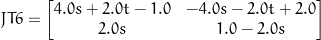

In [7]:
def J_T6(s, t, x):
    x1, y1 = x[0, :]
    x2, y2 = x[1, :]
    x3, y3 = x[2, :]
    x4, y4 = x[3, :]
    x5, y5 = x[4, :]
    x6, y6 = x[5, :]

    # Fonctions d'interpolation T6 (quadratiques)
    N1 = (1 - s - t)*(1 - 2*s - 2*t)
    N2 = s*(2*s - 1)
    N3 = t*(2*t - 1)
    N4 = 4*s*(1 - s - t)
    N5 = 4*s*t
    N6 = 4*t*(1 - s - t)

    # Interpolation de x(s,t) et y(s,t)
    x_st = N1*x1 + N2*x2 + N3*x3 + N4*x4 + N5*x5 + N6*x6
    y_st = N1*y1 + N2*y2 + N3*y3 + N4*y4 + N5*y5 + N6*y6

    # Dérivées partielles pour construire le Jacobien
    J = Matrix([
        [x_st.diff(s), y_st.diff(s)],
        [x_st.diff(t), y_st.diff(t)]
    ])

    return simplify(J)

points_ref = np.array(([0,0], [1,0], [0,1], [0,0.5], [0.5,0.5], [0,0.5]))
s, t = symbols('s t')
J = J_T6(s, t, points_ref)
plot_matrix(J, "JT6")

In [8]:
#calcul de la matrice B
A = np.array([
    [1, 0, 0, 0],  # d/dx
    [0, 0, 0, 1],  # d/dy
    [0, 1, 1, 0]   # d/dx + d/dy
])

def Mat_J_T6(noeuds, s, t):
    s_sym, t_sym = symbols('s t')
    J_sym = J_T6(s_sym, t_sym, noeuds)
    J_num = np.array(J_sym.evalf(subs={s_sym: s, t_sym: t})).astype(np.float64)

    Jblock = np.zeros((4, 4))
    Jblock[0:2, 0:2] = J_num
    Jblock[2:4, 2:4] = J_num

    return np.linalg.inv(Jblock)

def calculerB_T6(noeuds, s, t):
    J_inv_ext = Mat_J_T6(noeuds, s, t)   
    C = C_matrix_T6(s, t)                
    return A @ J_inv_ext @ C 

In [9]:
def calculerMatriceRigiditeLocale(connectivite_element, coordonnees):
    # Quadrature d'ordre 2 pour triangle (3 points)
    quads = [
        [1/6, 1/6],
        [2/3, 1/6],
        [1/6, 2/3]
    ]
    weights = [1/6, 1/6, 1/6] # C et J d'ordre 1 -> B d'ordre 2 -> BDB d'ordre 4 -> 3 pts de quadrature (4 <= 2*3-1 = 5)

    # Récupération des 6 nœuds de l'élément
    noeuds = coordonnees[connectivite_element.ravel(), :]  # (6,2)
    K_local = np.zeros((12, 12))

    # Symboles pour le Jacobien
    s_sym, t_sym = symbols('s t')

    for (s_val, t_val), w_q in zip(quads, weights):

        # Calcul du Jacobien au point (s,t)
        J_sym = J_T6(s_sym, t_sym, noeuds)
        J_num = np.array(J_sym.evalf(subs={s_sym: s_val, t_sym: t_val})).astype(np.float64)
        detJ = np.linalg.det(J_num)

        # Vérification que detJ n'est pas trop petit
        if np.abs(detJ) < 1e-10:
            raise ValueError(f"Dét(J) trop proche de 0 au point (s={s_val}, t={t_val}) : det(J) = {detJ}")

        # Calcul de la matrice B au point (s,t)
        B = calculerB_T6(noeuds, s_val, t_val)

        # Matrice de rigidité locale
        D = calculerD()
        K_local += w_q * (B.T @ D @ B) * detJ

    # Application de l'épaisseur
    epaisseur = 10.0  # mm
    return epaisseur * K_local


In [10]:
def calculerNumerosEquations(connectivite):

    n_elem  = connectivite.shape[0]
    n_nodes_per_elem = connectivite.shape[1]
    numEq = np.zeros((n_elem, 2*n_nodes_per_elem), dtype=int)
    for e in range(n_elem):
        for i in range(n_nodes_per_elem):
            numEq[e, 2*i]   = 2*connectivite[e, i];
            numEq[e, 2*i+1] = 2*connectivite[e, i]+1;
    return numEq

def assemblerMatriceRigidite(connectivite, coordonnees):

    n_elem  = connectivite.shape[0]
    n_nodes = coordonnees.shape[0]
    numEq = calculerNumerosEquations(connectivite)

    K = np.zeros((n_nodes*2, n_nodes*2))
    for e in range(n_elem):
        # On récupère les degrés de liberté de l'élément e
        ddl = numEq[e, :]
        # On récupère les noeuds de l'élément e
        connectivite_element = connectivite[e, :]
        # On calcule la matrice de rigidite locale de l'élément e
        K_locale = calculerMatriceRigiditeLocale(connectivite_element, coordonnees)
        # On assemble
        for i, gi in enumerate(ddl):
            for j, gj in enumerate(ddl):
                K[gi, gj] += K_locale[i, j]
    return K

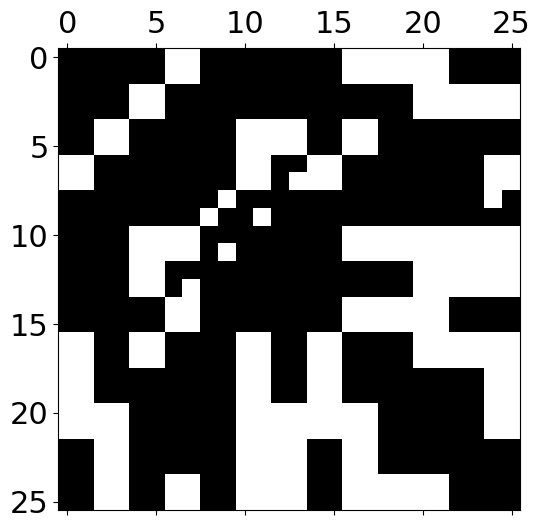

In [11]:
K = assemblerMatriceRigidite(conn_T6, points_T6)
plt.spy(K)

In [12]:
def calculerFtraction(nodes):
    """
    Applique une traction verticale totale de 200 N,
    correctement répartie entre les 3 nœuds du haut
    (1/6 - 4/6 - 1/6) en fonction de leur position.
    """
    n_nodes = nodes.shape[0]
    F = np.zeros((n_nodes, 2), dtype=float)

    force_totale = 200  # 200 N à répartir

    # Pondérations exactes
    poids_coin = 1/6
    poids_milieu = 4/6

    for index, node in enumerate(nodes):
        if node[1] == 1000.0:
            if node[0] == 500:  # Milieu d'arête 
                F[index, 1] = poids_milieu * force_totale
            else:  # Coin gauche (x=0) ou coin droit (x=1000)
                F[index, 1] = poids_coin * force_totale

    return F.ravel()

# Application
F = calculerFtraction(points_T6)
F

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  33.33333333,   0.        ,  33.33333333,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        , 133.33333333,   0.        ,   0.        ,
         0.        ,   0.        ])

In [13]:
def calculerBlocages(points):
    n_nodes = points.shape[0]
    blocages = np.zeros((n_nodes, 2), dtype=bool)

    for index, (x, y) in enumerate(points):
        if y == 0:
            blocages[index, 1] = True
        if x == 0:
            blocages[index, 0] = True

    return blocages.ravel()

blocages = calculerBlocages(points_T6)
libres = np.logical_not(blocages)
libres

array([False, False,  True, False, False,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True])

⚠️ Attention : champ vectoriel détecté, utilisation de la norme ||u||. Passez axis=0 ou axis=1 pour une composante spécifique.
[[ 0.00000000e+00  0.00000000e+00]
 [-2.85714286e-05  0.00000000e+00]
 [ 0.00000000e+00  9.52380952e-05]
 [-2.85714286e-05  9.52380952e-05]
 [-7.14285714e-06  2.38095238e-05]
 [-1.42857143e-05  0.00000000e+00]
 [-1.78571429e-05  1.19047619e-05]
 [-3.57142857e-06  1.19047619e-05]
 [-2.85714286e-05  4.76190476e-05]
 [-1.78571429e-05  5.95238095e-05]
 [-1.42857143e-05  9.52380952e-05]
 [-3.57142857e-06  5.95238095e-05]
 [ 0.00000000e+00  4.76190476e-05]]


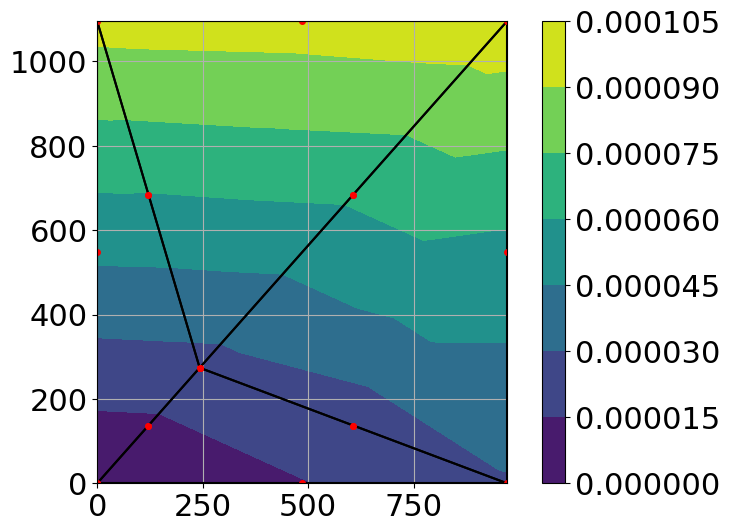

In [14]:
# --- Résolution du système Ku = F avec conditions aux limites ---
n_nodes = points_T6.shape[0]

# Initialisation du vecteur de déplacements
u = np.zeros(n_nodes * 2)

# Résolution uniquement sur les ddl libres
u[libres] = np.linalg.solve(K[libres, :][:, libres], F[libres])


plotT6Mesh(points_T6 + u.reshape(n_nodes, 2) * 1000000, conn_T6, u)
print(u.ravel().reshape((-1,2)))

In [15]:
# --- Calcul et affichage de la déformation globale epsilon pour T6 ---

# 1. Reformater le vecteur de déplacements
u_reshaped = u.reshape((n_nodes, 2))  # (n_nodes, 2) : (u_x, u_y)

# 2. Identifier les noeuds situés en haut (où y=1000 mm)
nodes_haut = np.where(points_T6[:,1] == 1000.0)[0]

# 3. Extraire les déplacements verticaux (u_y) des noeuds du haut
deplacements_haut = u_reshaped[nodes_haut, 1]  # composante verticale (y)

# 4. Calcul du déplacement moyen en haut
deplacement_moyen = np.mean(deplacements_haut)

# 5. Hauteur initiale du domaine
L = np.max(points_T6[:,1]) - np.min(points_T6[:,1])  # Différence entre y max et y min

# 6. Calcul de la déformation moyenne epsilon
epsilon = deplacement_moyen / L

# 7. Affichage clair
print("Déformation moyenne epsilon = {:.6e} (adimensionnel)".format(epsilon))
print("Déplacement moyen vertical en haut = {:.6e} mm".format(deplacement_moyen))
print("Hauteur initiale L = {:.6e} mm".format(L))


Déformation moyenne epsilon = 9.523810e-08 (adimensionnel)
Déplacement moyen vertical en haut = 9.523810e-05 mm
Hauteur initiale L = 1.000000e+03 mm


In [16]:
valeur_exacte = 0.02/210000
print(valeur_exacte)

a = np.abs(valeur_exacte-epsilon)
EcartRelatif = a/(valeur_exacte)
print(EcartRelatif)

if EcartRelatif < 1e-14:
    print("La solution est correcte")
else:
    print("La solution n'est pas correcte")

9.523809523809524e-08
5.558653716356346e-16
La solution est correcte


In [17]:
#Essai de cisaillement sur maillage initial
def calculerFshear(nodes):
    """
    Applique un cisaillement horizontal total de 200 N
    sur la face du haut (y=1000 mm),
    correctement réparti (1/6 - 4/6 - 1/6).
    """
    n_nodes = nodes.shape[0]
    F = np.zeros((n_nodes, 2), dtype=float)

    force_totale = 200  # 200 N à répartir horizontalement

    # Pondérations exactes
    poids_coin = 1/6
    poids_milieu = 4/6

    for index, node in enumerate(nodes):
        if node[1] == 1000.0:
            if node[0] == 500:  # Milieu d'arête (x=500 mm pour centre en 1m)
                F[index, 0] = poids_milieu * force_totale  # Force sur X
            else:  # Coin gauche (x=0) ou coin droit (x=1000)
                F[index, 0] = poids_coin * force_totale  # Force sur X

    return F.ravel()

# Application
F = calculerFshear(points_T6)

def calculerBlocages(points):
    n_nodes = points.shape[0]
    blocages = np.zeros((n_nodes, 2), dtype=bool)

    for index, (x, y) in enumerate(points):
        if y == 0:
            blocages[index, :] = True
        if y == 1000 or x == 0 or x == 1000:
            blocages[index, 1] = True

    return blocages.ravel()

blocages = calculerBlocages(points_T6)
libres = np.logical_not(blocages)
libres

array([False, False, False, False,  True, False,  True, False,  True,
        True, False, False,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True, False])

⚠️ Attention : champ vectoriel détecté, utilisation de la norme ||u||. Passez axis=0 ou axis=1 pour une composante spécifique.
[[ 0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [ 2.47619048e-04  0.00000000e+00]
 [ 2.47619048e-04  0.00000000e+00]
 [ 6.19047619e-05  1.99215730e-20]
 [ 0.00000000e+00  0.00000000e+00]
 [ 3.09523810e-05  1.66765383e-20]
 [ 3.09523810e-05 -1.17270882e-22]
 [ 1.23809524e-04  0.00000000e+00]
 [ 1.54761905e-04  6.49075858e-20]
 [ 2.47619048e-04  0.00000000e+00]
 [ 1.54761905e-04  6.61653086e-20]
 [ 1.23809524e-04  0.00000000e+00]]


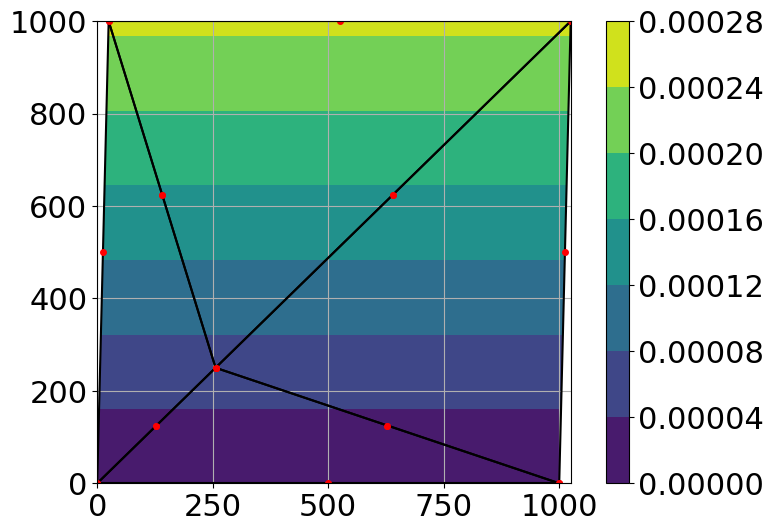

In [18]:
# --- Résolution du système Ku = F avec conditions aux limites ---
n_nodes = points_T6.shape[0]

# Initialisation du vecteur de déplacements
u = np.zeros(n_nodes * 2)

# Résolution uniquement sur les ddl libres
u[libres] = np.linalg.solve(K[libres, :][:, libres], F[libres])


plotT6Mesh(points_T6 + u.reshape(n_nodes, 2) * 100000, conn_T6, u)
print(u.ravel().reshape((-1,2)))

In [19]:
# --- Calcul et affichage de la déformation globale gamma_xy pour cisaillement T6 ---

# 1. Reformater le vecteur de déplacements
u_reshaped = u.reshape((n_nodes, 2))  # (n_nodes, 2) : (u_x, u_y)

# 2. Identifier les nœuds situés en haut et en bas
y = points_T6[:, 1]
eps = 1e-6
nodes_haut = np.where(np.isclose(y, np.max(y), atol=eps))[0]
nodes_bas  = np.where(np.isclose(y, np.min(y), atol=eps))[0]

# 3. Extraire les déplacements horizontaux (u_x) des nœuds du haut et du bas
ux_haut = np.mean(u_reshaped[nodes_haut, 0])
ux_bas  = np.mean(u_reshaped[nodes_bas, 0])

# 4. Hauteur initiale du domaine
L = np.max(y) - np.min(y)  # Hauteur (distance verticale)

# 5. Calcul de la déformation de cisaillement gamma_xy
gamma_xy = (ux_haut - ux_bas) / L

# 6. Affichage clair
print("\nDéformation moyenne gamma_xy = {:.6e} (adimensionnel)".format(gamma_xy))
print("Déplacement moyen horizontal en haut = {:.6e} mm".format(ux_haut))
print("Déplacement moyen horizontal en bas = {:.6e} mm".format(ux_bas))
print("Hauteur initiale L = {:.6e} mm".format(L))



Déformation moyenne gamma_xy = 2.476190e-07 (adimensionnel)
Déplacement moyen horizontal en haut = 2.476190e-04 mm
Déplacement moyen horizontal en bas = 0.000000e+00 mm
Hauteur initiale L = 1.000000e+03 mm


In [20]:
E = 210000
F = 200
tau_xy = 200/(1000*10)
epsilon_xy_exacte = 1.3*tau_xy/E

a2 = np.abs(epsilon_xy_exacte - gamma_xy/2)
EcartRelatif2 = a2/(epsilon_xy_exacte)
print(EcartRelatif2)

if EcartRelatif2 < 1e-14:
    print("La solution est correcte")
else:
    print("La solution n'est pas correcte")

2.9931212318841858e-15
La solution est correcte
